In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
from src.make_city_points import make_city_points

gdf = make_city_points()
gdf[gdf["city_name"] == "Phoenix"]

,city_id,city_name,state,climate_group,lat,lon,geometry
0,1,Phoenix,AZ,hot_arid,33.4484,-112.074,POINT (-112.074 33.4484)


In [3]:
from src.boundaries import build_urban_area_query_url

phoenix = gdf[gdf["city_name"] == "Phoenix"].iloc[0]

url = build_urban_area_query_url(
    lon=phoenix["lon"],
    lat=phoenix["lat"],
)
print(url)

https://tigerweb.geo.census.gov/arcgis/rest/services/Census2020/Urban/MapServer/1/query?f=geojson&where=1%3D1&geometry=-112.074%2C33.4484&geometryType=esriGeometryPoint&inSR=4326&spatialRel=esriSpatialRelIntersects&returnGeometry=true&outFields=GEOID%2CUA%2CBASENAME%2CNAME%2COBJECTID&resultRecordCount=1


In [4]:
from src.boundaries import fetch_urban_area_by_point

phoenix_boundary = fetch_urban_area_by_point(
    lon=phoenix["lon"],
    lat=phoenix["lat"],
)

phoenix_boundary

,GEOID,UA,BASENAME,NAME,OBJECTID,geometry
0,69184,69184,"Phoenix--Mesa--Scottsdale, AZ","Phoenix--Mesa--Scottsdale, AZ Urban Area",286,"MULTIPOLYGON (((-112.00887 33.29069, -112.0050..."


In [5]:
from src.boundaries import make_buffered_study_area

phoenix_study_area = make_buffered_study_area(phoenix_boundary, buffer_m=2000)
phoenix_study_area

,GEOID,UA,BASENAME,NAME,OBJECTID,geometry
0,69184,69184,"Phoenix--Mesa--Scottsdale, AZ","Phoenix--Mesa--Scottsdale, AZ Urban Area",286,"POLYGON ((362671.668 3722361.229, 362633.441 3..."


Text(0.5, 1.0, 'Phoenix Buffered Study Area')

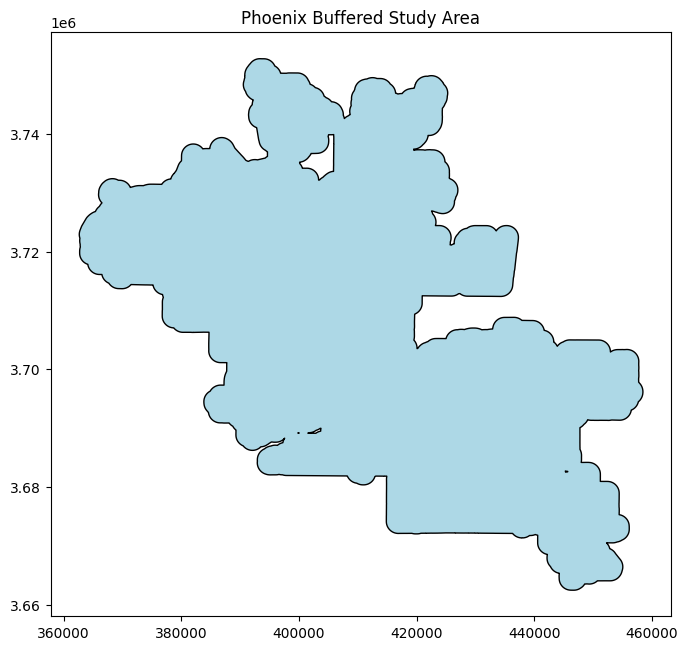

In [6]:
ax = phoenix_study_area.plot(figsize=(8, 8), edgecolor="black", facecolor="lightblue")
ax.set_title("Phoenix Buffered Study Area")

In [7]:
from src.grid import create_grid_from_polygon

phoenix_grid_centroids = create_grid_from_polygon(
    phoenix_study_area,
    resolution=30,
    return_geometry="centroid",
)

print(len(phoenix_grid_centroids))
phoenix_grid_centroids.head()

4743629


,cell_id,geometry
0,1,POINT (393165 3752895)
1,2,POINT (393195 3752895)
2,3,POINT (393225 3752895)
3,4,POINT (393255 3752895)
4,5,POINT (393285 3752895)


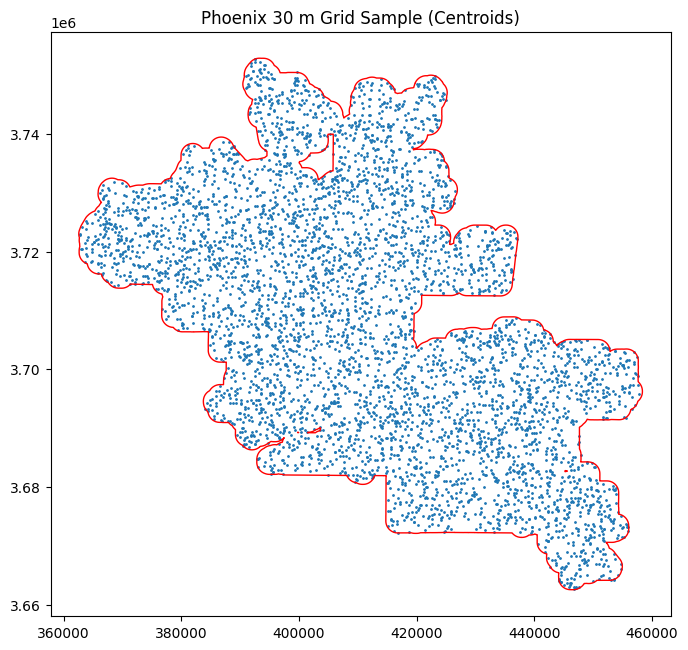

In [8]:
sample_centroids = phoenix_grid_centroids.sample(5000, random_state=1)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
sample_centroids.plot(ax=ax, markersize=1)
phoenix_study_area.boundary.plot(ax=ax, color="red", linewidth=1)
ax.set_title("Phoenix 30 m Grid Sample (Centroids)")
plt.show()

In [9]:
phoenix_grid_polygons = create_grid_from_polygon(
    phoenix_study_area,
    resolution=30,
    return_geometry="polygon",
)

print(len(phoenix_grid_polygons))
phoenix_grid_polygons.head()

4743629


,cell_id,geometry
0,1,"POLYGON ((393180 3752880, 393180 3752910, 3931..."
1,2,"POLYGON ((393210 3752880, 393210 3752910, 3931..."
2,3,"POLYGON ((393240 3752880, 393240 3752910, 3932..."
3,4,"POLYGON ((393270 3752880, 393270 3752910, 3932..."
4,5,"POLYGON ((393300 3752880, 393300 3752910, 3932..."


C:\Users\golde\OneDrive\Documents\STAT5630_FinalProject_DataProcessing\figures\phoenix_grid_sample_centroids.png


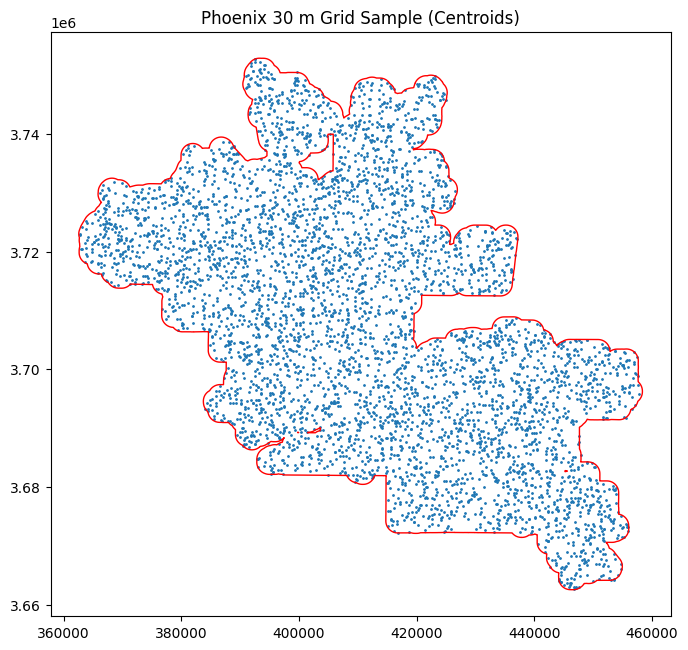

In [10]:
sample_centroids = phoenix_grid_centroids.sample(5000, random_state=1)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
sample_centroids.plot(ax=ax, markersize=1)
phoenix_study_area.boundary.plot(ax=ax, color="red", linewidth=1)
ax.set_title("Phoenix 30 m Grid Sample (Centroids)")

output_path = PROJECT_ROOT / "figures" / "phoenix_grid_sample_centroids.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)
plt.show()